# Tugas 4: Implementasi Feature Selection dan Feature Engineering
**Nama:** Panji Kurnia Akbar  
**NIM:** 2024081024  
**Tgl:** 10 Maret 2026  
**Mata Kuliah:** Introduction to AI  

---
Dataset yang digunakan: `top_anime_dataset.csv` — berisi informasi anime seperti skor, episode, popularitas, dll.  
**Target Prediksi:** `score`

In [1]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")

Library berhasil diimport!


## STEP 1 — Load Data & Preview
Langkah pertama adalah memuat dataset dan melihat 5 baris pertama untuk memahami struktur data yang ada.

In [2]:
# Load dataset
df = pd.read_csv('top_anime_dataset.csv')

# Pilih kolom yang akan digunakan
columns_used = ['score', 'episodes', 'popularity', 'members', 'favorites', 'type']
df = df[columns_used].copy()

print("Shape dataset:", df.shape)
print("\nTipe data setiap kolom:")
print(df.dtypes)
print("\n5 Baris Pertama Dataset:")
df.head()

Shape dataset: (500, 6)

Tipe data setiap kolom:
score         float64
episodes      float64
popularity      int64
members         int64
favorites       int64
type              str
dtype: object

5 Baris Pertama Dataset:


,score,episodes,popularity,members,favorites,type
0,9.28,28.0,108,1353494,85889,TV
1,9.16,10.0,644,414180,5476,TV
2,9.11,64.0,3,3645704,240910,TV
3,9.09,1.0,643,414906,12097,Movie
4,9.07,24.0,14,2786505,201170,TV


**Interpretasi STEP 1:**  
Dataset berhasil dimuat dengan memilih 6 kolom relevan: `score` (target), `episodes`, `popularity`, `members`, `favorites` (fitur numerik), dan `type` (fitur kategorikal). Kita perlu melakukan preprocessing sebelum bisa menggunakan data ini untuk modeling.

---
## STEP 2 — Feature Engineering
Feature Engineering adalah proses mengolah dan mentransformasi data mentah menjadi fitur yang lebih baik untuk model machine learning.  
Ada 3 teknik yang diterapkan di sini:
1. **Missing Value Handling** — Mengisi nilai kosong pada kolom `episodes` dengan nilai median.
2. **One-Hot Encoding** — Mengubah kolom kategorikal `type` menjadi kolom numerik biner.
3. **Scaling** — Menyamakan skala semua fitur numerik dengan StandardScaler.

### STEP 2A — Missing Value Handling (Median Imputation pada `episodes`)

In [3]:
# Cek missing value sebelum handling
print("=== Missing Value Sebelum Handling ===")
print(df.isnull().sum())
print()

# Hapus baris di mana target 'score' kosong (tidak bisa diprediksi)
df = df.dropna(subset=['score'])

# Impute kolom 'episodes' dengan median
imputer = SimpleImputer(strategy='median')
df['episodes'] = imputer.fit_transform(df[['episodes']])

print("=== Missing Value Setelah Handling ===")
print(df.isnull().sum())

=== Missing Value Sebelum Handling ===
score         0
episodes      8
popularity    0
members       0
favorites     0
type          0
dtype: int64

=== Missing Value Setelah Handling ===
score         0
episodes      0
popularity    0
members       0
favorites     0
type          0
dtype: int64


**Interpretasi STEP 2A:**  
Kolom `episodes` memiliki beberapa nilai kosong (missing values). Daripada menghapus baris tersebut (yang berarti kehilangan data), kita isi dengan nilai **median**. Median dipilih karena lebih tahan terhadap outlier dibanding mean — cocok untuk data episodes yang bisa sangat bervariasi (misalnya anime pendek vs anime panjang).

### STEP 2B — One-Hot Encoding pada kolom `type`

In [4]:
# Cek nilai unik kolom 'type'
print("Nilai unik pada kolom 'type':")
print(df['type'].value_counts())
print()

# One-Hot Encoding menggunakan pd.get_dummies
# drop_first=True untuk menghindari multikolinearitas (dummy variable trap)
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True, dtype=int)

print("Kolom setelah One-Hot Encoding:")
print(df_encoded.columns.tolist())
print("\nShape dataset setelah encoding:", df_encoded.shape)
df_encoded.head()

Nilai unik pada kolom 'type':
type
TV            297
Movie         114
ONA            44
OVA            17
TV Special     11
Special         9
Music           7
PV              1
Name: count, dtype: int64

Kolom setelah One-Hot Encoding:
['score', 'episodes', 'popularity', 'members', 'favorites', 'type_Music', 'type_ONA', 'type_OVA', 'type_PV', 'type_Special', 'type_TV', 'type_TV Special']

Shape dataset setelah encoding: (500, 12)


,score,episodes,popularity,members,favorites,type_Music,type_ONA,type_OVA,type_PV,type_Special,type_TV,type_TV Special
0,9.28,28.0,108,1353494,85889,0,0,0,0,0,1,0
1,9.16,10.0,644,414180,5476,0,0,0,0,0,1,0
2,9.11,64.0,3,3645704,240910,0,0,0,0,0,1,0
3,9.09,1.0,643,414906,12097,0,0,0,0,0,0,0
4,9.07,24.0,14,2786505,201170,0,0,0,0,0,1,0


**Interpretasi STEP 2B:**  
Kolom `type` berisi data kategorikal (TV, Movie, OVA, dll.) yang tidak bisa langsung diproses oleh model numerik. Dengan **One-Hot Encoding**, setiap kategori diubah menjadi kolom biner tersendiri (0 atau 1). Parameter `drop_first=True` digunakan untuk menghindari *dummy variable trap* (multikolinearitas) — yaitu kondisi di mana satu kolom bisa ditebak dari kolom lainnya.

### STEP 2C — Feature Scaling dengan StandardScaler

In [5]:
# Pisahkan fitur (X) dan target (y)
X = df_encoded.drop(columns=['score'])
y = df_encoded['score']

# Identifikasi kolom numerik yang perlu di-scaling
# (tidak termasuk kolom hasil one-hot encoding karena sudah biner 0/1)
numerical_features = ['episodes', 'popularity', 'members', 'favorites']

# Terapkan StandardScaler hanya pada fitur numerik
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

print("Statistik fitur numerik SEBELUM scaling:")
print(X[numerical_features].describe().round(2))
print()
print("Statistik fitur numerik SETELAH scaling:")
print(X_scaled[numerical_features].describe().round(4))

Statistik fitur numerik SEBELUM scaling:
       episodes  popularity     members  favorites
count    500.00      500.00      500.00     500.00
mean      18.26     1559.43   578917.52   13815.25
std       35.14     1919.38   692476.04   29497.77
min        1.00        1.00     2212.00      24.00
25%        1.00      294.75   113331.25     852.00
50%       12.00      839.50   329616.50    3453.50
75%       24.00     2174.25   772173.75   13553.75
max      500.00    12270.00  4316356.00  249284.00

Statistik fitur numerik SETELAH scaling:
       episodes  popularity   members  favorites
count  500.0000    500.0000  500.0000   500.0000
mean    -0.0000     -0.0000    0.0000    -0.0000
std      1.0010      1.0010    1.0010     1.0010
min     -0.4915     -0.8128   -0.8337    -0.4680
25%     -0.4915     -0.6596   -0.6730    -0.4399
50%     -0.1782     -0.3755   -0.3604    -0.3516
75%      0.1636      0.3206    0.2794    -0.0089
max     13.7222      5.5858    5.4026     7.9906


**Interpretasi STEP 2C:**  
Fitur numerik seperti `members` bisa bernilai jutaan, sementara `episodes` hanya puluhan. Perbedaan skala ini bisa membuat model machine learning "bingung" dan memberikan bobot lebih pada fitur dengan nilai besar. **StandardScaler** mengubah setiap fitur agar memiliki **mean = 0** dan **standard deviation = 1**, sehingga semua fitur berada dalam skala yang setara.

---
## STEP 3 — Feature Selection
Feature Selection adalah proses memilih fitur-fitur yang paling relevan dan berpengaruh terhadap target (`score`), sehingga model menjadi lebih efisien dan akurat.  
Ada 2 teknik yang digunakan:
1. **Correlation Heatmap** — Visualisasi korelasi antar fitur untuk melihat hubungan linear.
2. **Univariate Selection (SelectKBest)** — Secara statistik memilih fitur terbaik berdasarkan skor F-regression.

### STEP 3A — Correlation Heatmap

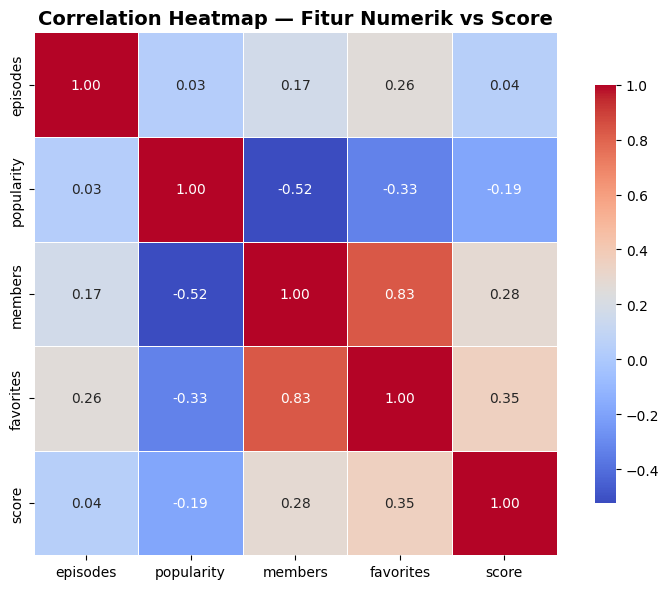


Nilai korelasi setiap fitur terhadap 'score':
favorites     0.354449
members       0.280742
episodes      0.044330
popularity   -0.188152
Name: score, dtype: float64


In [6]:
# Gabungkan X_scaled dengan y untuk menghitung korelasi
df_corr = X_scaled[numerical_features].copy()
df_corr['score'] = y.values

# Hitung matriks korelasi
correlation_matrix = df_corr.corr()

# Plot Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Fitur Numerik vs Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNilai korelasi setiap fitur terhadap 'score':")
print(correlation_matrix['score'].drop('score').sort_values(ascending=False))

**Interpretasi STEP 3A:**  
Dari heatmap, kita bisa melihat seberapa kuat hubungan linear antara setiap fitur dengan `score`. Nilai korelasi mendekati **+1** artinya hubungan positif kuat (fitur naik → score naik), mendekati **-1** artinya hubungan negatif kuat, dan mendekati **0** artinya hampir tidak ada hubungan linear. Misalnya, `favorites` dan `members` cenderung berkorelasi positif dengan `score` karena anime yang bagus biasanya punya banyak penggemar.

### STEP 3B — Univariate Selection dengan SelectKBest (f_regression)

=== Hasil Univariate Selection (SelectKBest, k=3) ===
          Fitur  F-Score  P-Value  Terpilih
      favorites    71.56 0.000000      True
        members    42.61 0.000000      True
     popularity    18.28 0.000023      True
        type_TV     3.10 0.078905     False
       type_OVA     1.78 0.182981     False
   type_Special     1.58 0.209841     False
       episodes     0.98 0.322536     False
type_TV Special     0.82 0.365341     False
       type_ONA     0.18 0.674346     False
     type_Music     0.14 0.703907     False
        type_PV     0.05 0.826068     False

✅ 3 Fitur Terbaik yang Dipilih: ['favorites', 'members', 'popularity']


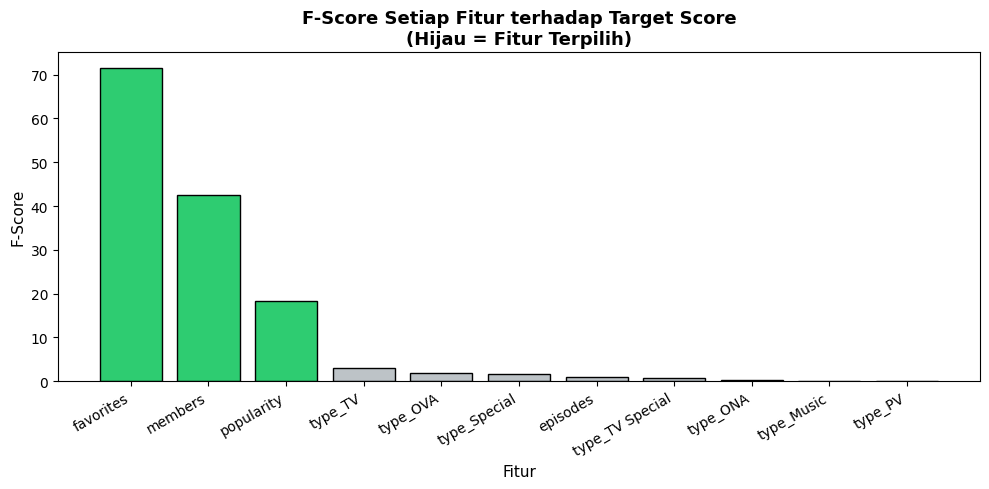

In [7]:
# Terapkan SelectKBest dengan scoring function f_regression
# k=3 berarti kita pilih 3 fitur terbaik
selector = SelectKBest(score_func=f_regression, k=3)
selector.fit(X_scaled, y)

# Ambil skor F-statistic setiap fitur
feature_names = X_scaled.columns.tolist()
f_scores = selector.scores_
p_values = selector.pvalues_

# Buat DataFrame hasil seleksi untuk tampilan rapi
selection_df = pd.DataFrame({
    'Fitur': feature_names,
    'F-Score': f_scores.round(2),
    'P-Value': p_values.round(6),
    'Terpilih': selector.get_support()
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print("=== Hasil Univariate Selection (SelectKBest, k=3) ===")
print(selection_df.to_string(index=False))

# Tampilkan 3 fitur terbaik yang terpilih
best_features = selection_df[selection_df['Terpilih'] == True]['Fitur'].tolist()
print(f"\n✅ 3 Fitur Terbaik yang Dipilih: {best_features}")

# Visualisasi F-Score menggunakan bar chart
plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if selected else '#bdc3c7' for selected in selection_df['Terpilih']]
bars = plt.bar(selection_df['Fitur'], selection_df['F-Score'], color=colors, edgecolor='black')
plt.title('F-Score Setiap Fitur terhadap Target Score\n(Hijau = Fitur Terpilih)', fontsize=13, fontweight='bold')
plt.xlabel('Fitur', fontsize=11)
plt.ylabel('F-Score', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Interpretasi STEP 3B:**  
**SelectKBest** dengan `f_regression` menghitung **F-Statistic** antara setiap fitur dengan target `score`. F-Score yang tinggi berarti fitur tersebut memiliki hubungan statistik yang signifikan dengan target. Fitur dengan F-Score tertinggi (ditandai warna hijau) adalah fitur yang paling "informatif" untuk memprediksi `score`. P-value yang mendekati 0 mengkonfirmasi bahwa hubungan tersebut bukan kebetulan semata.

---
## Kesimpulan

Berikut rangkuman seluruh proses yang telah dilakukan dalam tugas ini:

| Tahap | Teknik | Tujuan |
|-------|--------|--------|
| Feature Engineering | Missing Value Handling (Median) | Mengisi nilai kosong di kolom `episodes` |
| Feature Engineering | One-Hot Encoding | Mengubah kolom kategorikal `type` menjadi numerik |
| Feature Engineering | StandardScaler | Menyamakan skala semua fitur numerik |
| Feature Selection | Correlation Heatmap | Visualisasi hubungan antar fitur dengan target |
| Feature Selection | SelectKBest (f_regression) | Memilih 3 fitur terbaik secara statistik |

**Insight Utama:**  
Dari proses Feature Engineering dan Feature Selection yang telah dilakukan, dataset `top_anime_dataset.csv` kini siap digunakan untuk membangun model prediksi `score`. Fitur-fitur yang terpilih oleh SelectKBest adalah yang paling berkontribusi dalam memprediksi seberapa tinggi skor suatu anime — yang pada umumnya berkaitan erat dengan seberapa populer dan disukai anime tersebut oleh komunitas MAL (MyAnimeList).